# Task 1: Deep Comparison — CIC-IDS2017 vs Live Capture
### Why does XGBoost fail on PortScan, and what separates SSH/FTP-Patator success from PortScan failure?

This notebook:
1. Does a **statistical + visual deep-dive** comparing PortScan flows
2. Uses **SHAP** to show what features drive misclassifications
3. Compares why SSH/FTP-Patator works but PortScan doesn't 

In [1]:
import shap
print(shap.__version__)

0.51.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


## 1. Load All Data

In [3]:
# ── CIC-IDS2017 training files ──────────────────────────────────────────────
# UPDATE these paths to your local CIC files
tue = pd.read_csv(r"C:\Users\magan\Downloads\MachineLearningCSV\MachineLearningCVE\Tuesday-WorkingHours.pcap_ISCX.csv")
fri = pd.read_csv(r"C:\Users\magan\Downloads\MachineLearningCSV\MachineLearningCVE\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")

# ── Your live captures ───────────────────────────────────────────────────────
live1 = pd.read_csv(r"C:\Users\magan\Downloads\HPE Project\label_realdata_flows.csv")
live2 = pd.read_csv(r"C:\Users\magan\Downloads\HPE Project\port_brute_labeled.csv")

# Strip all column whitespace
for df in [tue, fri, live1, live2]:
    df.columns = df.columns.str.strip()

# Rename 'Label' column in CIC data (it has a leading space before stripping)
print('CIC Friday labels:', fri['Label'].value_counts().to_dict())
print('Live1 labels:', live1['Label'].value_counts().to_dict())
print('Live2 labels:', live2['Label'].value_counts().to_dict())

CIC Friday labels: {'PortScan': 158930, 'BENIGN': 127537}
Live1 labels: {'PortScan': 16983, 'BENIGN': 8577, 'BruteForce': 149}
Live2 labels: {'PortScan': 75700, 'BENIGN': 7633, 'FTP-BruteForce': 454, 'SSH-BruteForce': 110}


## 2. Align Column Names (CICFlowMeter version differences)

In [ ]:
# CIC-IDS2017 was generated with an older CICFlowMeter — column names differ slightly
# Live captures used a newer version. This rename map normalizes everything.
LIVE_TO_CIC = {
    'Dst Port':                  'Destination Port',
    'Total Fwd Packet':          'Total Fwd Packets',
    'Total Bwd packets':         'Total Backward Packets',
    'Total Length of Fwd Packet':'Total Length of Fwd Packets',
    'Total Length of Bwd Packet':'Total Length of Bwd Packets',
    'Packet Length Min':         'Min Packet Length',
    'Packet Length Max':         'Max Packet Length',
    'Fwd Segment Size Avg':      'Avg Fwd Segment Size',
    'Bwd Segment Size Avg':      'Avg Bwd Segment Size',
    'FWD Init Win Bytes':        'Init_Win_bytes_forward',
    'Bwd Init Win Bytes':        'Init_Win_bytes_backward',
    'Fwd Act Data Pkts':         'act_data_pkt_fwd',
    'Fwd Seg Size Min':          'min_seg_size_forward',
    'CWR Flag Count':            'CWE Flag Count',
}

live1 = live1.rename(columns=LIVE_TO_CIC)
live2 = live2.rename(columns=LIVE_TO_CIC)

# Also fix label inconsistency in live1
live1['Label'] = live1['Label'].replace({'BruteForce': 'SSH-Patator'})
live2['Label'] = live2['Label'].replace({'SSH-BruteForce': 'SSH-Patator', 'FTP-BruteForce': 'FTP-Patator'})

print('Renamed. Live2 labels now:', live2['Label'].value_counts().to_dict())


Renamed. Live2 labels now: {'PortScan': 75700, 'BENIGN': 7633, 'FTP-Patator': 454, 'SSH-Patator': 110}


## 3. Build Comparison DataFrames

In [5]:
# Features we will compare — exclude meta columns
META_COLS = ['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Protocol', 'Timestamp', 'Label']

# CIC PortScan from Friday file
cic_portscan  = fri[fri['Label'] == 'PortScan'].copy()
cic_benign    = fri[fri['Label'] == 'BENIGN'].copy()
cic_ssh       = tue[tue['Label'] == 'SSH-Patator'].copy()
cic_ftp       = tue[tue['Label'] == 'FTP-Patator'].copy()

# Live data splits
live_portscan = pd.concat([live1[live1['Label']=='PortScan'], live2[live2['Label']=='PortScan']])
live_benign   = pd.concat([live1[live1['Label']=='BENIGN'],   live2[live2['Label']=='BENIGN']])
live_ssh      = pd.concat([live1[live1['Label']=='SSH-Patator'], live2[live2['Label']=='SSH-Patator']])
live_ftp      = live2[live2['Label']=='FTP-Patator']

print(f'CIC  PortScan: {len(cic_portscan):>6}  |  Live PortScan: {len(live_portscan):>6}')
print(f'CIC  BENIGN  : {len(cic_benign):>6}  |  Live BENIGN  : {len(live_benign):>6}')
print(f'CIC  SSH     : {len(cic_ssh):>6}  |  Live SSH     : {len(live_ssh):>6}')
print(f'CIC  FTP     : {len(cic_ftp):>6}  |  Live FTP     : {len(live_ftp):>6}')

CIC  PortScan: 158930  |  Live PortScan:  92683
CIC  BENIGN  : 127537  |  Live BENIGN  :  16210
CIC  SSH     :   5897  |  Live SSH     :    259
CIC  FTP     :   7938  |  Live FTP     :    454


## 4. Statistical Comparison — Key Flow Features

In [6]:
# The most discriminative features for network attack detection
KEY_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s',
    'SYN Flag Count', 'RST Flag Count', 'FIN Flag Count', 'ACK Flag Count', 'PSH Flag Count',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean',
    'Fwd Packets/s', 'Bwd Packets/s',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward',
]

def safe_stats(df, features):
    """Return median and IQR for each feature, safe against missing cols."""
    rows = []
    for f in features:
        if f in df.columns:
            col = pd.to_numeric(df[f], errors='coerce').replace([np.inf, -np.inf], np.nan)
            rows.append({'Feature': f,
                         'Median': col.median(),
                         'Mean':   col.mean(),
                         'Std':    col.std(),
                         'P25':    col.quantile(0.25),
                         'P75':    col.quantile(0.75)})
        else:
            rows.append({'Feature': f, 'Median': np.nan, 'Mean': np.nan,
                         'Std': np.nan, 'P25': np.nan, 'P75': np.nan})
    return pd.DataFrame(rows).set_index('Feature')

cic_ps_stats  = safe_stats(cic_portscan, KEY_FEATURES)
live_ps_stats = safe_stats(live_portscan, KEY_FEATURES)
cic_b_stats   = safe_stats(cic_benign, KEY_FEATURES)
live_b_stats  = safe_stats(live_benign, KEY_FEATURES)

comparison = pd.concat({
    'CIC_PortScan':  cic_ps_stats['Median'],
    'Live_PortScan': live_ps_stats['Median'],
    'CIC_BENIGN':    cic_b_stats['Median'],
    'Live_BENIGN':   live_b_stats['Median'],
}, axis=1)

print('=== MEDIAN VALUES: CIC vs Live PortScan and BENIGN ===')
print(comparison.to_string())

=== MEDIAN VALUES: CIC vs Live PortScan and BENIGN ===
                         CIC_PortScan  Live_PortScan  CIC_BENIGN  Live_BENIGN
Feature                                                                      
Flow Duration                 47.0000        70.0000  30964.0000  135899.0000
Total Fwd Packets              1.0000         1.0000      2.0000       1.0000
Total Backward Packets         1.0000         1.0000      2.0000       1.0000
Flow Bytes/s              139534.8837         0.0000   5681.1763    3223.0171
Flow Packets/s             42553.1915     28169.0141    112.6338      30.4938
SYN Flag Count                 0.0000         1.0000      0.0000       0.0000
RST Flag Count                 0.0000         1.0000      0.0000       0.0000
FIN Flag Count                 0.0000         0.0000      0.0000       0.0000
ACK Flag Count                 0.0000         1.0000      0.0000       0.0000
PSH Flag Count                 1.0000         0.0000      0.0000       0.0000
Fwd Packe

### Analysis

#### Differences between CIC PortScan and Live_Portscan: -

+ `Flow Bytes/s` in CIC_Portscan but none in Live
+ `SYN, RST, ACK Flag count` 1 in Live
+ No `PSH flag` in live! 
+ `Init_Win_bytes_forward` live portscan has median value which is very low when compared to CIC's 
+ `Bwd Packet Length Mean` is 0 in live

#### CIC Benign Vs Live:

+ `Total Fwd Packets` , `Total Backward Packets` in CIC have a median of 2 whereas in live it's just 1 which is more towards portscan traffic.
+ `Init_win_bytes_backwards` there is -1 in CIC but in live nothing and that resembles more like portscan, `Init_Win_bytes_forward` there is nothing.
+ `Flow packets/s` values is too low in live .

Despite these differences in benign capture. CIC didn't misclassify a single benign packet ----> Controversy checked at the end.

## 5. Visual Comparison — Distribution Plots (PortScan: CIC vs Live)

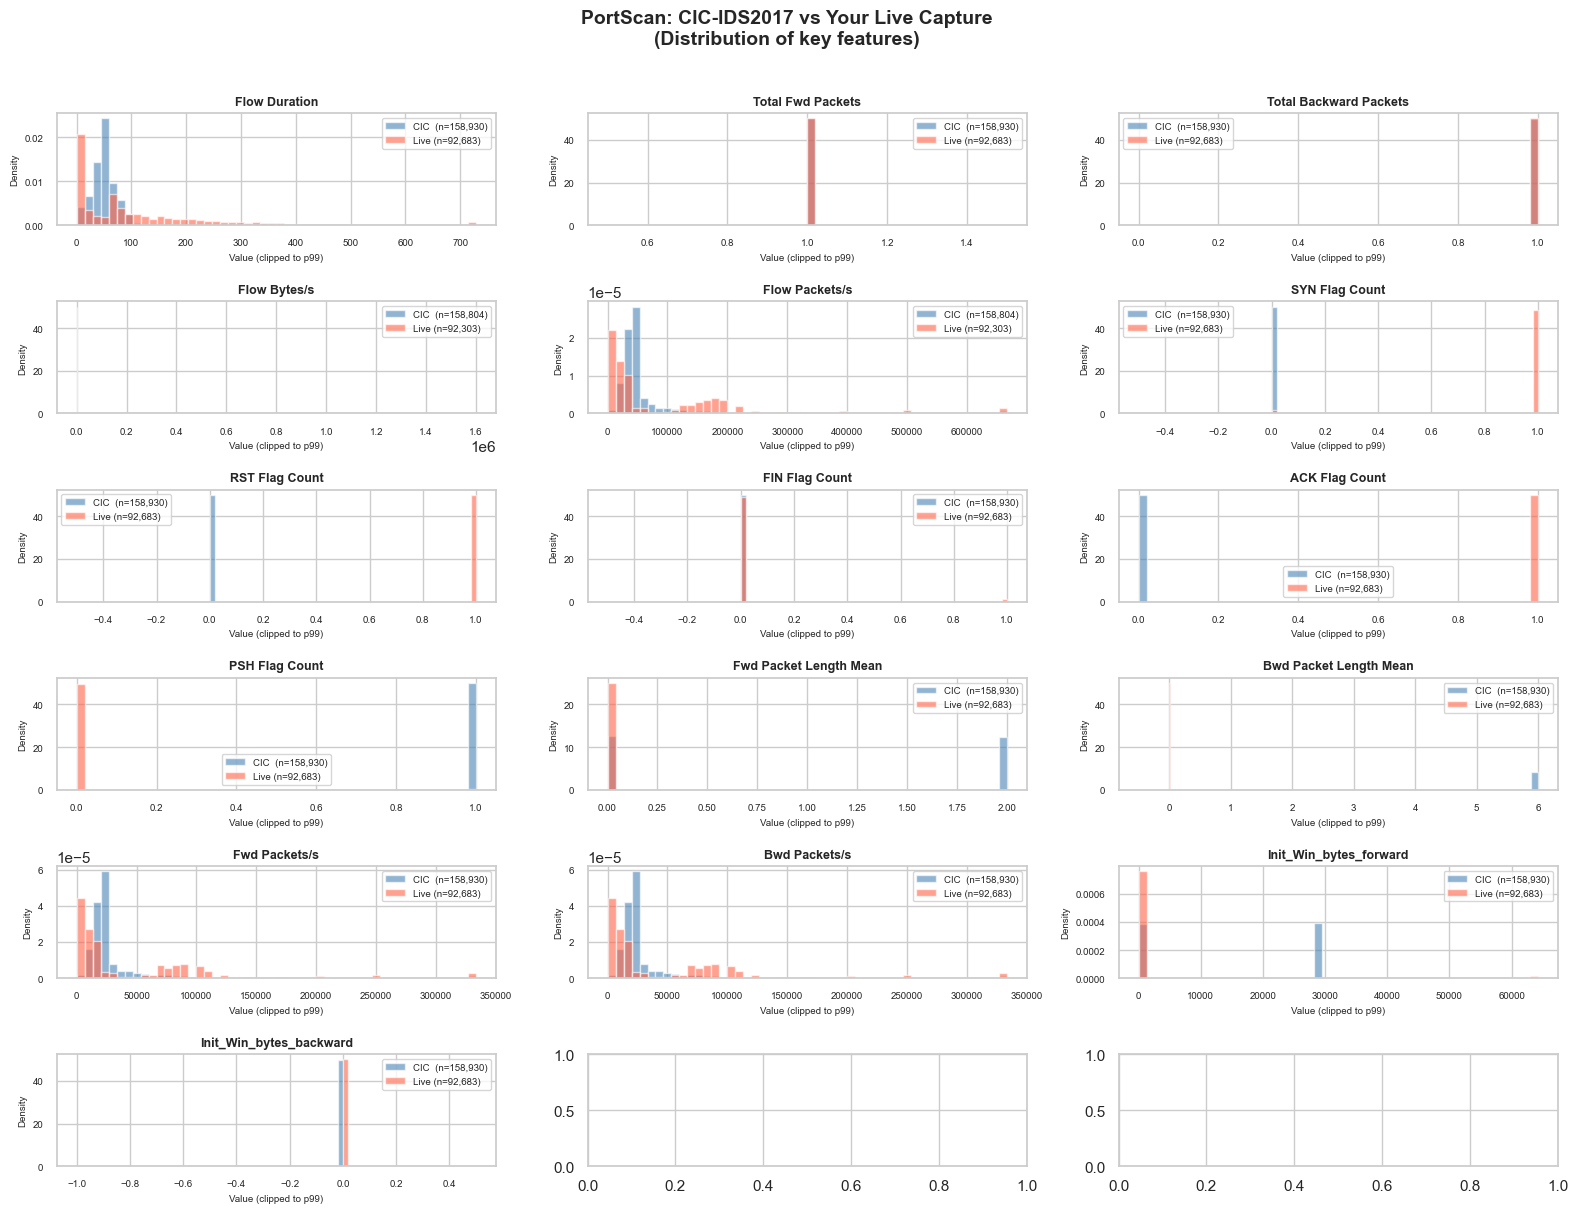

Saved: portscan_distribution_comparison.png


In [23]:
PLOT_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count',
    'Fwd Packet Length Mean', 'Init_Win_bytes_forward', 'Flow Packets/s'
]

fig, axes = plt.subplots(6, 3, figsize=(16, 12))
fig.suptitle('PortScan: CIC-IDS2017 vs Your Live Capture\n(Distribution of key features)', 
             fontsize=14, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), KEY_FEATURES):
    cic_vals  = pd.to_numeric(cic_portscan[feat], errors='coerce').replace([np.inf,-np.inf], np.nan).dropna()
    live_vals = pd.to_numeric(live_portscan[feat], errors='coerce').replace([np.inf,-np.inf], np.nan).dropna()
    
    # Clip to 99th percentile to avoid extreme outlier skew
    p99 = max(cic_vals.quantile(0.99), live_vals.quantile(0.99))
    cic_vals  = cic_vals.clip(upper=p99)
    live_vals = live_vals.clip(upper=p99)
    
    ax.hist(cic_vals,  bins=50, alpha=0.6, color='steelblue', density=True, label=f'CIC  (n={len(cic_vals):,})')
    ax.hist(live_vals, bins=50, alpha=0.6, color='tomato',    density=True, label=f'Live (n={len(live_vals):,})')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value (clipped to p99)', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('portscan_distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: portscan_distribution_comparison.png')

## 6. Visual Comparison — SSH/FTP Patator: CIC vs Live
*(This is why brute-force works but PortScan doesn't)*

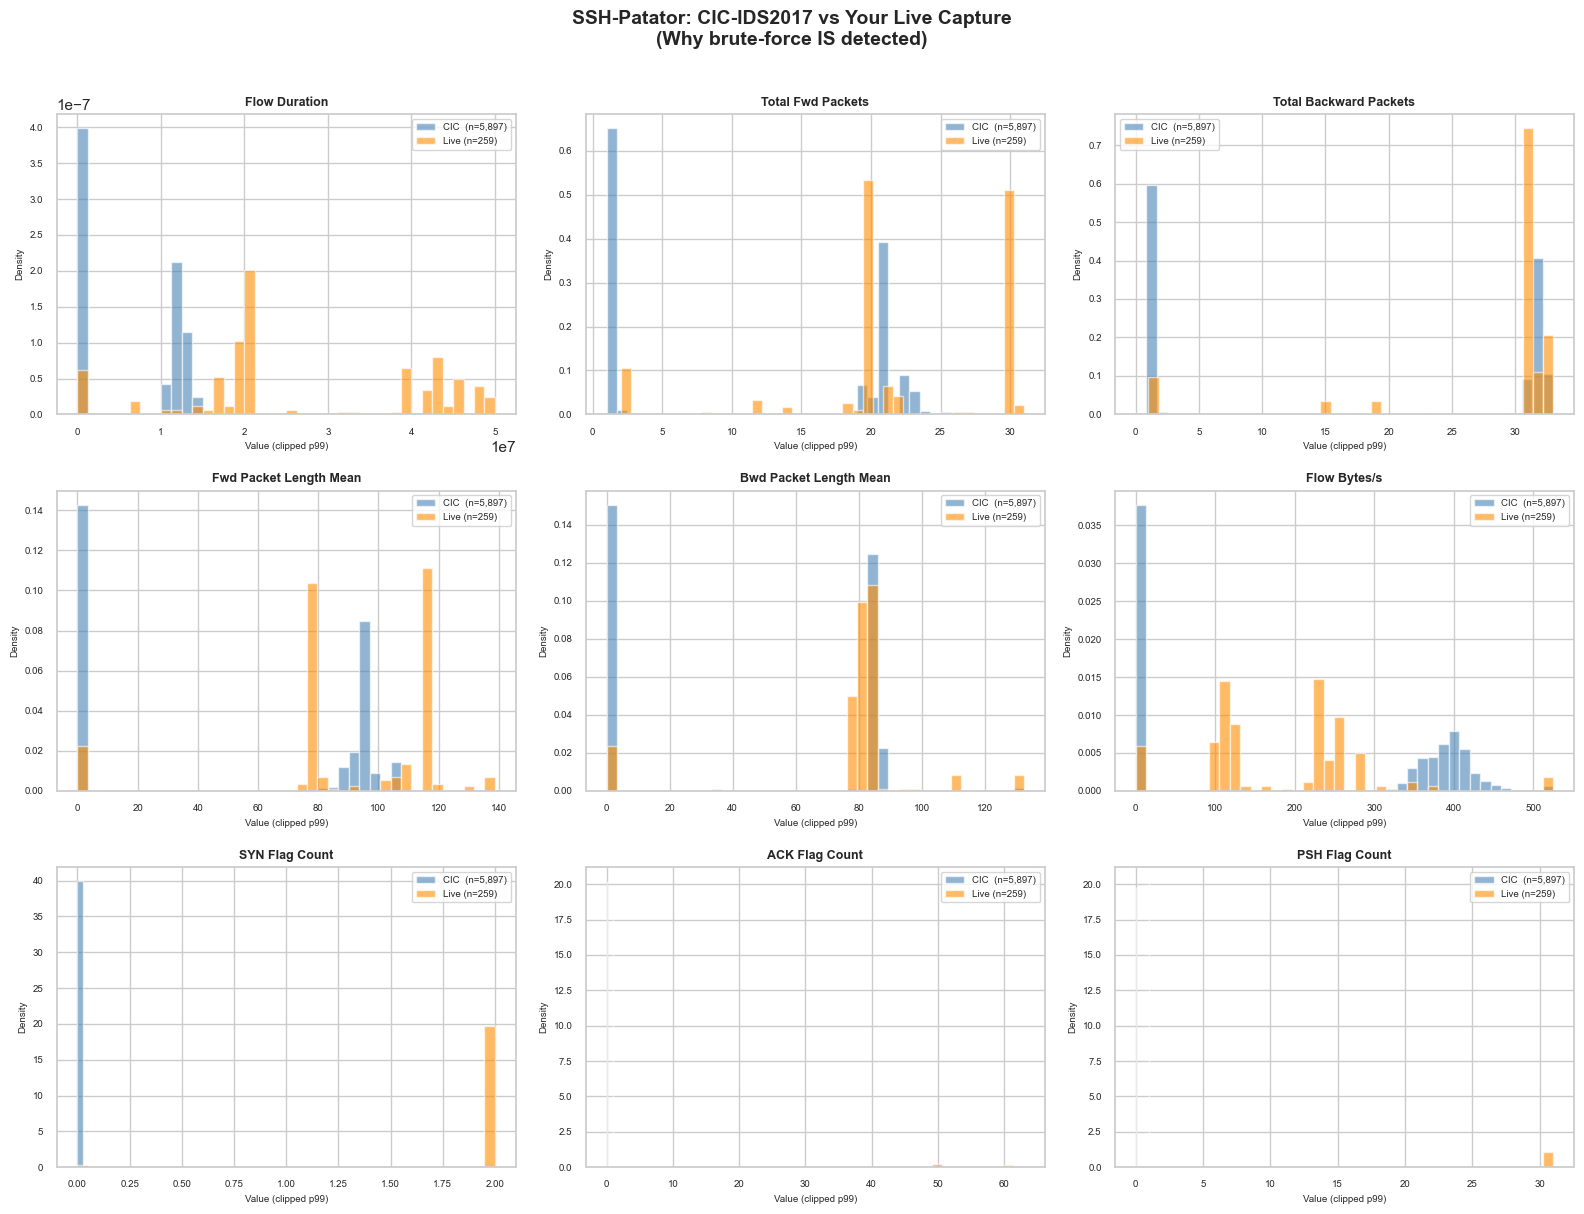

Saved: ssh_patator_comparison.png


In [8]:
BRUTE_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Flow Bytes/s',
    'SYN Flag Count', 'ACK Flag Count', 'PSH Flag Count'
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('SSH-Patator: CIC-IDS2017 vs Your Live Capture\n(Why brute-force IS detected)', 
             fontsize=14, fontweight='bold', y=1.01)

for ax, feat in zip(axes.flatten(), BRUTE_FEATURES):
    cic_vals  = pd.to_numeric(cic_ssh[feat], errors='coerce').replace([np.inf,-np.inf], np.nan).dropna()
    live_vals = pd.to_numeric(live_ssh[feat], errors='coerce').replace([np.inf,-np.inf], np.nan).dropna()
    
    if len(cic_vals) == 0 or len(live_vals) == 0:
        ax.set_title(f'{feat} (no data)', fontsize=8)
        continue
    
    p99 = max(cic_vals.quantile(0.99), live_vals.quantile(0.99))
    cic_vals  = cic_vals.clip(upper=p99)
    live_vals = live_vals.clip(upper=p99)
    
    ax.hist(cic_vals,  bins=40, alpha=0.6, color='steelblue', density=True, label=f'CIC  (n={len(cic_vals):,})')
    ax.hist(live_vals, bins=40, alpha=0.6, color='darkorange', density=True, label=f'Live (n={len(live_vals):,})')
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value (clipped p99)', fontsize=7)
    ax.set_ylabel('Density', fontsize=7)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('ssh_patator_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ssh_patator_comparison.png')

## 7. Flag Profile Heatmap — All Classes at Once

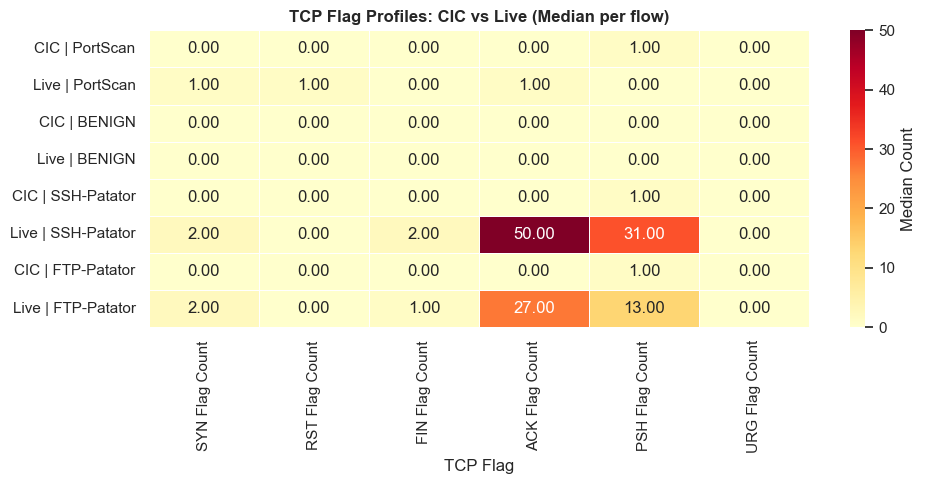

Saved: flag_profile_heatmap.png


In [9]:
FLAG_COLS = ['SYN Flag Count','RST Flag Count','FIN Flag Count',
             'ACK Flag Count','PSH Flag Count','URG Flag Count']

def flag_profile(df, label, source):
    row = {'Label': label, 'Source': source}
    for f in FLAG_COLS:
        if f in df.columns:
            row[f] = pd.to_numeric(df[f], errors='coerce').median()
        else:
            row[f] = 0
    return row

profiles = pd.DataFrame([
    flag_profile(cic_portscan,  'PortScan',    'CIC'),
    flag_profile(live_portscan, 'PortScan',    'Live'),
    flag_profile(cic_benign,    'BENIGN',      'CIC'),
    flag_profile(live_benign,   'BENIGN',      'Live'),
    flag_profile(cic_ssh,       'SSH-Patator', 'CIC'),
    flag_profile(live_ssh,      'SSH-Patator', 'Live'),
    flag_profile(cic_ftp,       'FTP-Patator', 'CIC'),
    flag_profile(live_ftp,      'FTP-Patator', 'Live'),
])

profiles.index = profiles['Source'] + ' | ' + profiles['Label']
profiles = profiles[FLAG_COLS]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profiles.astype(float), annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Median Count'})
ax.set_title('TCP Flag Profiles: CIC vs Live (Median per flow)', fontsize=12, fontweight='bold')
ax.set_xlabel('TCP Flag')
plt.tight_layout()
plt.savefig('flag_profile_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: flag_profile_heatmap.png')

## 8. Retrain XGBoost (same config as original notebook) for SHAP analysis

In [10]:
# Rebuild training data exactly as in the original notebook
df_train = pd.concat([tue, fri], axis=0)
df_train.columns = df_train.columns.str.strip()

zero_features = ["Bwd PSH Flags","Fwd URG Flags","Bwd URG Flags","CWE Flag Count",
                 "Fwd Avg Bytes/Bulk","Fwd Avg Packets/Bulk","Fwd Avg Bulk Rate",
                 "Bwd Avg Bytes/Bulk","Bwd Avg Packets/Bulk","Bwd Avg Bulk Rate"]
drop_cols = zero_features + ["Fwd Header Length.1"]
df_train = df_train.drop(columns=[c for c in drop_cols if c in df_train.columns])

X_tr = df_train.drop('Label', axis=1)
y_tr = df_train['Label']

le = LabelEncoder()
y_enc = le.fit_transform(y_tr)

X_tr = X_tr.replace([np.inf, -np.inf], np.nan).fillna(0)
X_tr = X_tr.apply(pd.to_numeric, errors='coerce').fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X_tr, y_enc, test_size=0.1, stratify=y_enc, random_state=42)

xg = xgb.XGBClassifier(
    objective='multi:softprob', num_class=len(le.classes_),
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', random_state=42, eval_metric='mlogloss'
)
xg.fit(X_train, y_train)

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Label mapping:', label_mapping)
print('Model trained.')

Label mapping: {'BENIGN': np.int64(0), 'FTP-Patator': np.int64(1), 'PortScan': np.int64(2), 'SSH-Patator': np.int64(3)}
Model trained.


## 9. Prepare Live Data for Prediction (mirroring original notebook pipeline)

In [11]:
# Combine live1 + live2
live_all = pd.concat([live1, live2], axis=0).reset_index(drop=True)

# Drop columns not used in training
drop_live = zero_features + ['Flow ID','Src IP','Src Port','Dst IP','Timestamp','Protocol']
live_all_d = live_all.drop(columns=[c for c in drop_live if c in live_all.columns])

# Keep only columns that exist in training set
train_feature_cols = [c for c in X_tr.columns]
missing_in_live = [c for c in train_feature_cols if c not in live_all_d.columns]
extra_in_live   = [c for c in live_all_d.columns if c not in train_feature_cols and c != 'Label']
print('Features in training but MISSING from live:', missing_in_live)
print('Extra columns in live (dropped):', extra_in_live)

live_all_d = live_all_d.drop(columns=[c for c in extra_in_live if c in live_all_d.columns])

# Add any missing columns as 0
for c in missing_in_live:
    live_all_d[c] = 0

# Reorder to match training
X_live = live_all_d[[c for c in train_feature_cols]].apply(pd.to_numeric, errors='coerce')
X_live = X_live.replace([np.inf,-np.inf], np.nan).fillna(X_live.median())

y_live_raw  = live_all['Label']
y_live_enc  = le.transform(y_live_raw)

print('X_live shape:', X_live.shape)
print('Classes:', le.classes_)

Features in training but MISSING from live: []
Extra columns in live (dropped): ['Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg', 'Bwd Bytes/Bulk Avg', 'Bwd Packet/Bulk Avg', 'Bwd Bulk Rate Avg']
X_live shape: (109606, 67)
Classes: ['BENIGN' 'FTP-Patator' 'PortScan' 'SSH-Patator']


## 10. Confusion Matrix — Full Live Dataset

=== Classification Report on Live Data ===
              precision    recall  f1-score   support

      BENIGN       0.15      1.00      0.26     16210
 FTP-Patator       1.00      0.69      0.81       454
    PortScan       0.99      0.01      0.02     92683
 SSH-Patator       1.00      0.93      0.96       259

    accuracy                           0.16    109606
   macro avg       0.79      0.66      0.51    109606
weighted avg       0.87      0.16      0.06    109606



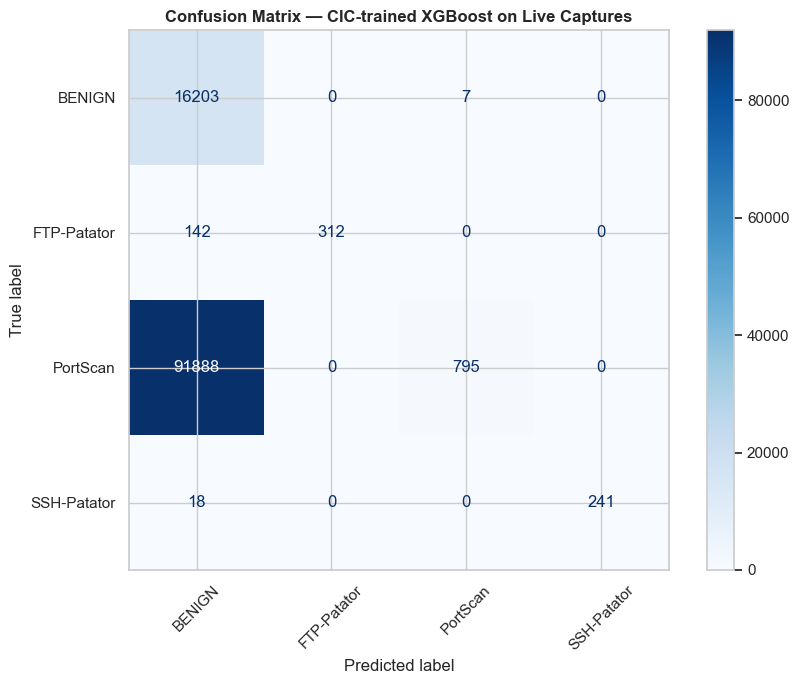

Saved: confusion_matrix_live.png


In [12]:
y_pred_live = xg.predict(X_live)

print('=== Classification Report on Live Data ===')
print(classification_report(y_live_enc, y_pred_live, target_names=le.classes_))

cm = confusion_matrix(y_live_enc, y_pred_live)
fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — CIC-trained XGBoost on Live Captures', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_live.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix_live.png')

## 11. SHAP Analysis — What Features Drive PortScan Misclassification?

In [13]:
# Build SHAP explainer on the trained model
# We'll explain predictions on live PortScan flows specifically
print('Building SHAP explainer... (may take 1-2 minutes)')
explainer = shap.TreeExplainer(xg)

# Grab live PortScan rows only — sample 500 for speed
ps_idx    = live_all[live_all['Label'] == 'PortScan'].index
ps_sample = X_live.loc[ps_idx].sample(min(500, len(ps_idx)), random_state=42)

shap_values = explainer.shap_values(ps_sample)  # shape: (n_samples, n_features, n_classes)

# PortScan class index
ps_class_idx = label_mapping['PortScan']

print(f'SHAP computed. PortScan class index = {ps_class_idx}')
print(f'Shape of SHAP values: {np.array(shap_values).shape}')

Building SHAP explainer... (may take 1-2 minutes)
SHAP computed. PortScan class index = 2
Shape of SHAP values: (500, 67, 4)


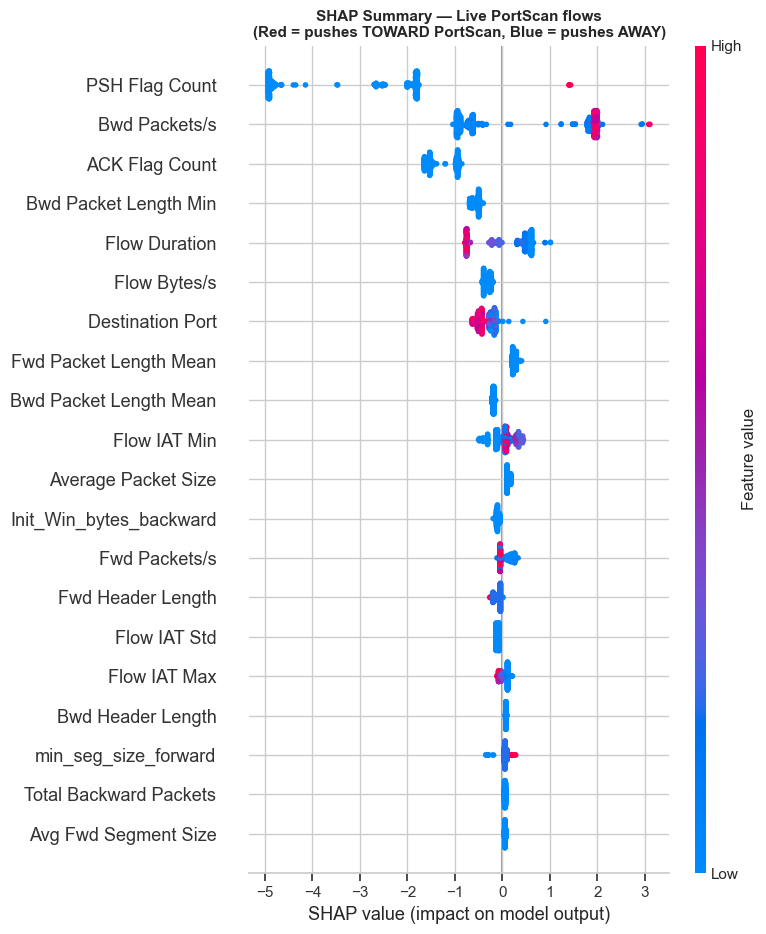

Saved: shap_portscan_summary.png


In [14]:
# SHAP summary plot for PortScan class — what pushes a flow TOWARD or AWAY from PortScan prediction
shap_ps = np.array(shap_values)[:, :, ps_class_idx] if np.array(shap_values).ndim == 3 else shap_values[ps_class_idx]

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_ps, ps_sample,
    max_display=20,
    show=False,
    plot_type='dot'
)
plt.title('SHAP Summary — Live PortScan flows\n(Red = pushes TOWARD PortScan, Blue = pushes AWAY)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_portscan_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_portscan_summary.png')

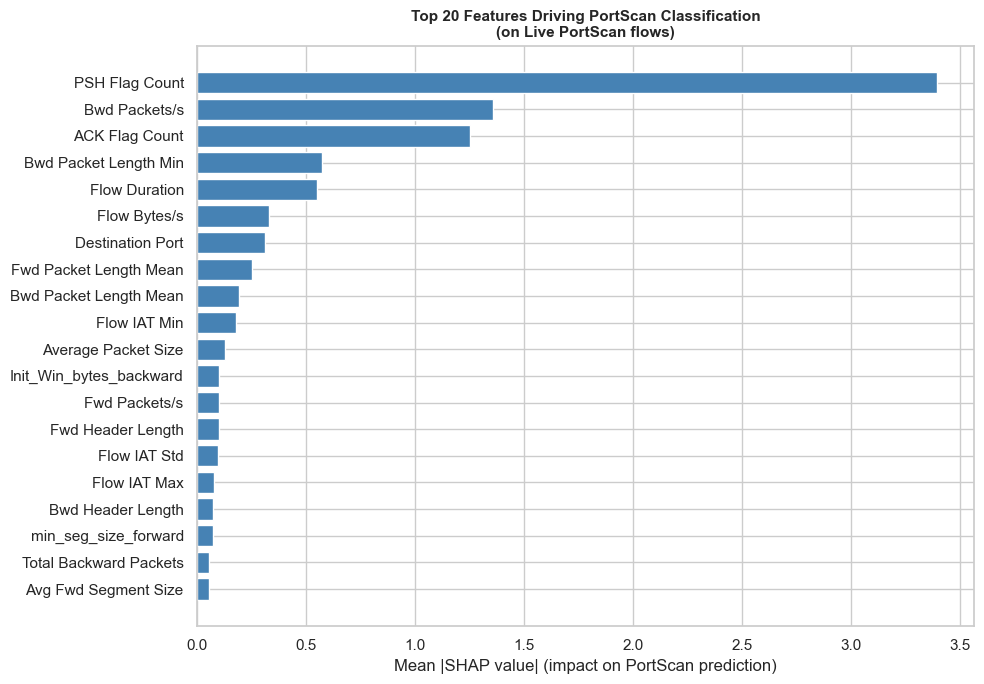

Top 10 PortScan-driving features:
               Feature  Mean |SHAP|
        PSH Flag Count       3.3947
         Bwd Packets/s       1.3564
        ACK Flag Count       1.2538
 Bwd Packet Length Min       0.5744
         Flow Duration       0.5521
          Flow Bytes/s       0.3317
      Destination Port       0.3117
Fwd Packet Length Mean       0.2519
Bwd Packet Length Mean       0.1934
          Flow IAT Min       0.1800


In [15]:
# SHAP bar plot — mean absolute impact per feature for PortScan class
mean_shap = np.abs(shap_ps).mean(axis=0)
shap_df = pd.DataFrame({'Feature': ps_sample.columns, 'Mean |SHAP|': mean_shap})\
            .sort_values('Mean |SHAP|', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(shap_df['Feature'][::-1], shap_df['Mean |SHAP|'][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value| (impact on PortScan prediction)')
ax.set_title('Top 20 Features Driving PortScan Classification\n(on Live PortScan flows)', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_portscan_bar.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 PortScan-driving features:')
print(shap_df.head(10).to_string(index=False))

## 12. SHAP for SSH-Patator — Why it works (comparison)

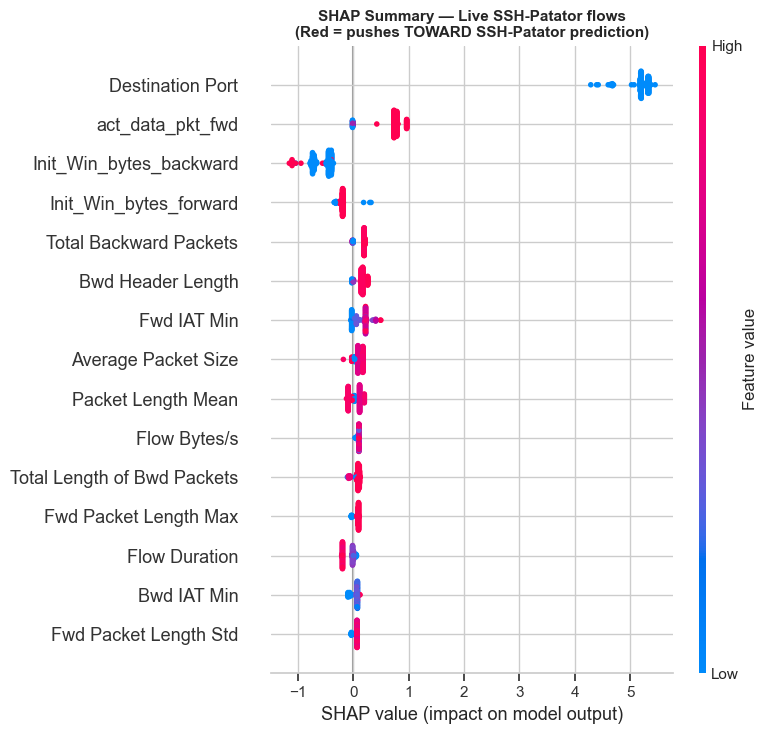

Saved: shap_ssh_summary.png


In [16]:
ssh_idx    = live_all[live_all['Label'] == 'SSH-Patator'].index
if len(ssh_idx) > 0:
    ssh_sample = X_live.loc[ssh_idx].sample(min(200, len(ssh_idx)), random_state=42)
    shap_ssh_all = explainer.shap_values(ssh_sample)
    ssh_class_idx = label_mapping.get('SSH-Patator', None)
    
    if ssh_class_idx is not None:
        shap_ssh = np.array(shap_ssh_all)[:, :, ssh_class_idx] if np.array(shap_ssh_all).ndim == 3 else shap_ssh_all[ssh_class_idx]
        
        plt.figure(figsize=(10, 7))
        shap.summary_plot(shap_ssh, ssh_sample, max_display=15, show=False, plot_type='dot')
        plt.title('SHAP Summary — Live SSH-Patator flows\n(Red = pushes TOWARD SSH-Patator prediction)',
                  fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig('shap_ssh_summary.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: shap_ssh_summary.png')
    else:
        print('SSH-Patator not in label encoder classes — check label mapping.')
else:
    print('No SSH-Patator flows in live data.')

## 13. Misclassification Breakdown — What is PortScan predicted AS?

=== Live PortScan flows predicted as: ===
  BENIGN              :  91888 (99.1%)
  PortScan            :    795 (0.9%)


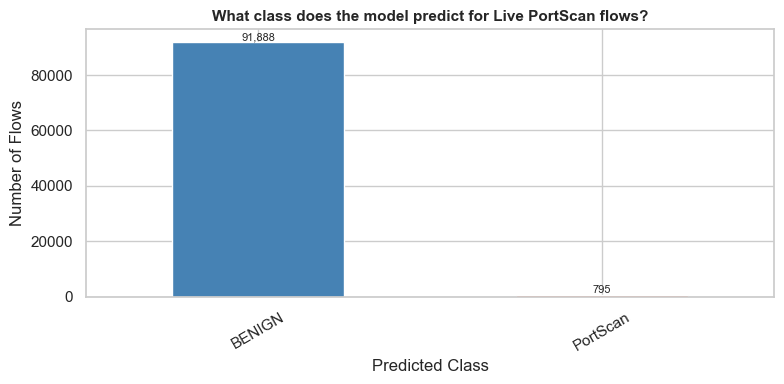

Saved: portscan_predicted_as.png


In [17]:
live_ps_mask = live_all['Label'] == 'PortScan'
X_ps_only    = X_live[live_ps_mask.values]
y_ps_true    = y_live_enc[live_ps_mask.values]
y_ps_pred    = xg.predict(X_ps_only)

pred_labels  = le.inverse_transform(y_ps_pred)
pred_counts  = pd.Series(pred_labels).value_counts()

print('=== Live PortScan flows predicted as: ===')
for cls, cnt in pred_counts.items():
    pct = cnt / len(pred_labels) * 100
    print(f'  {cls:<20}: {cnt:>6} ({pct:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
pred_counts.plot(kind='bar', ax=ax, color=['tomato' if c=='PortScan' else 'steelblue' for c in pred_counts.index])
ax.set_title('What class does the model predict for Live PortScan flows?', fontsize=11, fontweight='bold')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Number of Flows')
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(ax.patches, pred_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('portscan_predicted_as.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: portscan_predicted_as.png')

## 14. Feature Value Comparison — Correctly vs Incorrectly Classified PortScan

Correctly classified as PortScan  : 795
Incorrectly classified (missed)   : 91,888


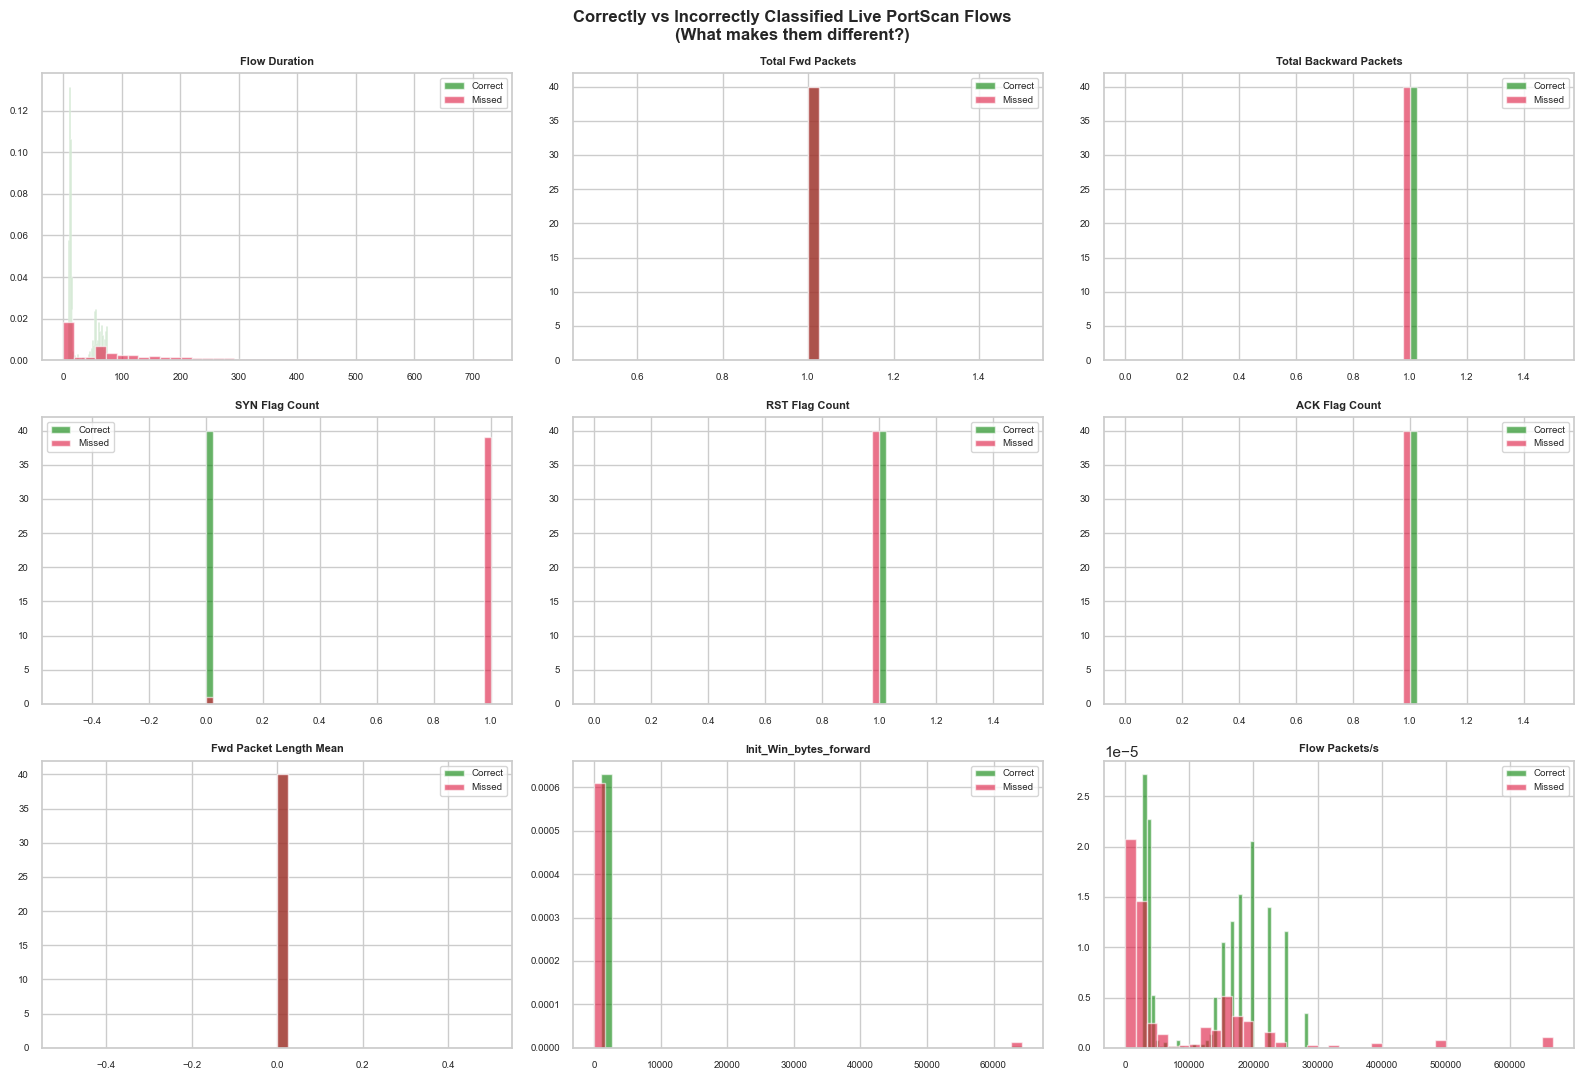

Saved: portscan_correct_vs_missed.png


In [18]:
# Split live PortScan into correct vs incorrect predictions
ps_class_idx_val = label_mapping['PortScan']
correct_mask   = (y_ps_pred == ps_class_idx_val)
incorrect_mask = ~correct_mask

ps_correct   = X_ps_only[correct_mask]
ps_incorrect = X_ps_only[incorrect_mask]

print(f'Correctly classified as PortScan  : {correct_mask.sum():,}')
print(f'Incorrectly classified (missed)   : {incorrect_mask.sum():,}')

if len(ps_correct) > 0 and len(ps_incorrect) > 0:
    compare_feats = ['Flow Duration','Total Fwd Packets','Total Backward Packets',
                     'SYN Flag Count','RST Flag Count','ACK Flag Count',
                     'Fwd Packet Length Mean','Init_Win_bytes_forward','Flow Packets/s']
    compare_feats = [f for f in compare_feats if f in X_ps_only.columns]
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 11))
    fig.suptitle('Correctly vs Incorrectly Classified Live PortScan Flows\n(What makes them different?)',
                 fontsize=12, fontweight='bold')
    
    for ax, feat in zip(axes.flatten(), compare_feats):
        c_vals = ps_correct[feat].replace([np.inf,-np.inf], np.nan).dropna()
        i_vals = ps_incorrect[feat].replace([np.inf,-np.inf], np.nan).dropna()
        p99 = max(c_vals.quantile(0.99) if len(c_vals) else 1,
                  i_vals.quantile(0.99) if len(i_vals) else 1)
        ax.hist(c_vals.clip(upper=p99),  bins=40, alpha=0.6, color='green',  density=True, label='Correct')
        ax.hist(i_vals.clip(upper=p99),  bins=40, alpha=0.6, color='crimson', density=True, label='Missed')
        ax.set_title(feat, fontsize=8, fontweight='bold')
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)
    
    plt.tight_layout()
    plt.savefig('portscan_correct_vs_missed.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: portscan_correct_vs_missed.png')
else:
    print('Not enough data in one category to compare.')

Clearly correctly guess packets resemble more of CICIDS traffic

## 15. Summary — Why PortScan Fails and SSH/FTP Succeeds

=== FINAL COMPARISON TABLE (Median values) ===
                    Flow Duration  Total Fwd Packets  Total Backward Packets  SYN Flag Count  RST Flag Count  ACK Flag Count  PSH Flag Count  Fwd Packet Length Mean  Init_Win_bytes_forward
Dataset                                                                                                                                                                                     
CIC | PortScan            47.0000             1.0000                  1.0000          0.0000          0.0000          0.0000          1.0000                  0.0000              29200.0000
Live | PortScan           70.0000             1.0000                  1.0000          1.0000          1.0000          1.0000          0.0000                  0.0000               1024.0000
CIC | BENIGN           30964.0000             2.0000                  2.0000          0.0000          0.0000          0.0000          0.0000                 37.0000                 52.0000
Live | B

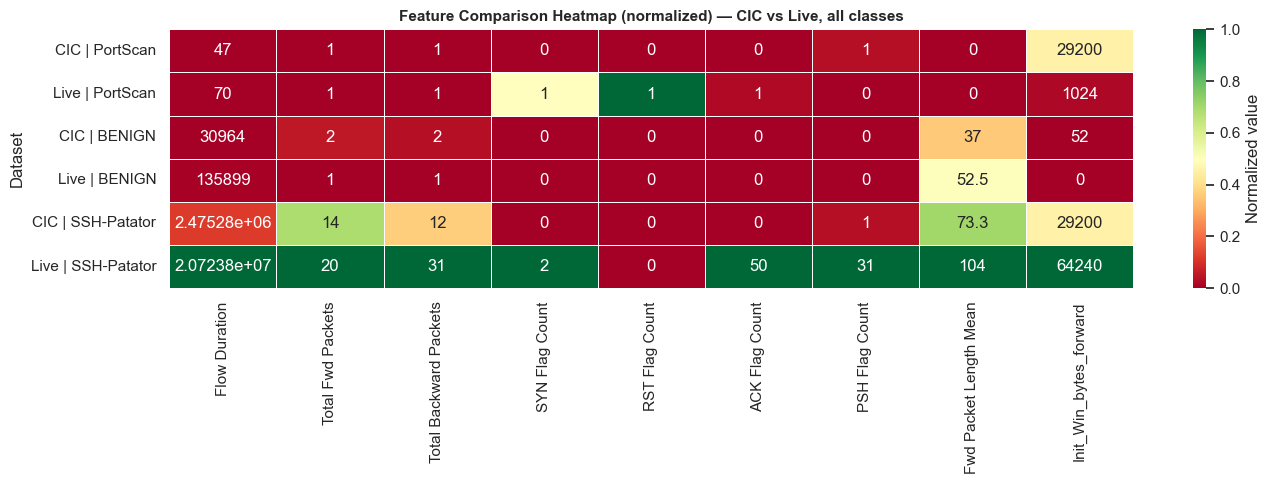

Saved: final_comparison_heatmap.png


In [19]:
# Final summary comparison table
summary_features = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
                    'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'PSH Flag Count',
                    'Fwd Packet Length Mean', 'Init_Win_bytes_forward']

def median_row(df, features):
    return {f: round(pd.to_numeric(df[f], errors='coerce').replace([np.inf,-np.inf],np.nan).median(), 2)
            for f in features if f in df.columns}

rows = [
    {'Dataset': 'CIC | PortScan',    **median_row(cic_portscan,  summary_features)},
    {'Dataset': 'Live | PortScan',   **median_row(live_portscan, summary_features)},
    {'Dataset': 'CIC | BENIGN',      **median_row(cic_benign,    summary_features)},
    {'Dataset': 'Live | BENIGN',     **median_row(live_benign,   summary_features)},
    {'Dataset': 'CIC | SSH-Patator', **median_row(cic_ssh,       summary_features)},
    {'Dataset': 'Live | SSH-Patator',**median_row(live_ssh,      summary_features)},
]

summary_df = pd.DataFrame(rows).set_index('Dataset')
print('=== FINAL COMPARISON TABLE (Median values) ===')
print(summary_df.to_string())

# Heatmap of the summary
fig, ax = plt.subplots(figsize=(14, 5))
# Normalize each column to 0-1 for visual comparison
norm_df = summary_df.apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9))
sns.heatmap(norm_df, annot=summary_df.round(1), fmt='g', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized value'})
ax.set_title('Feature Comparison Heatmap (normalized) — CIC vs Live, all classes',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_comparison_heatmap.png')

In [20]:
# Check what % of your live PortScan flows have each flag combination
live_portscan_flags = live_portscan[['SYN Flag Count','RST Flag Count',
                                      'ACK Flag Count','PSH Flag Count','FIN Flag Count']]
print(live_portscan_flags.apply(pd.to_numeric, errors='coerce').describe())

# The 795 flows that WERE correctly detected — what made them different?
# Already done in cell 35 but add this:
print('\nCorrectly detected PortScan PSH Flag distribution:')
print(ps_correct['PSH Flag Count'].value_counts().head())
print('\nMissed PortScan PSH Flag distribution:')
print(ps_incorrect['PSH Flag Count'].value_counts().head())

       SYN Flag Count  RST Flag Count  ACK Flag Count  PSH Flag Count  \
count      92683.0000      92683.0000      92683.0000      92683.0000   
mean           0.9675          1.0000          1.0000          0.0108   
std            0.1773          0.0057          0.0057          0.1035   
min            0.0000          0.0000          0.0000          0.0000   
25%            1.0000          1.0000          1.0000          0.0000   
50%            1.0000          1.0000          1.0000          0.0000   
75%            1.0000          1.0000          1.0000          0.0000   
max            1.0000          1.0000          1.0000          1.0000   

       FIN Flag Count  
count      92683.0000  
mean           0.0216  
std            0.1454  
min            0.0000  
25%            0.0000  
50%            0.0000  
75%            0.0000  
max            1.0000  

Correctly detected PortScan PSH Flag distribution:
PSH Flag Count
1    795
Name: count, dtype: int64

Missed PortScan PSH Fla

Need to add benign SSH traffic and test the model for false postiives